<img src="../Imagens/Cabecalho.png"/>

# <div align="center"> "PINN inversa": descobrindo a equação diferencial </div>

`Autor`: Giulio Oertel Spinelli Roux César

------------------------------

# 1. Objetivo do *notebook*

O objetivo desse *notebook* é aplicar de forma didática uma PINN ao problema de encontrar os parâmetros de uma Equação Diferencial. Para tanto, analisamos o problema de Resfriamento de Newton, o mais simples possível, através de uma MLP (a fim de comparação) e de uma PINN. 

Lei de Resfriamento de Newton.
$$
\frac{\mathrm d}{\mathrm d t}T(t) =  r\,(T_{amb} - T(t))
$$
Em que $T(t)$ é a temperatura do sistema ao longo do tempo, $r$ é a taxa de resfriamento, $T_{\mathrm{amb}}$ é a temperatura ambiente.

**Conhecimentos prévios:** A fim de compreender o *notebook*, espera-se conhecimentos básicos de Equações Diferenciais (não como resolvê-las, mas estar familiarizado com sua estrutura) e de aprendizado de máquina, bem como contato prévio com `PyTorch`. Também espera-se que tenha lido o *notebook* `Basica_PINN.ipynb`, onde montamos uma PINN passo a passo que será usada como base aqui.

**`Importante`**: Este *notebook* acompanha dois arquivos auxiliares chamados `funcoes.py` e `NeuralNetworks.py`. Em funcoes.py estão funções auxiliares, permitindo que o *notebook* seja focado em ensinar sobre PINNs, sem longos desvios. E em NeuralNetworks.py está definida uma MLP usada para comparação.

-------------------------------

# 2. Introdução

Vamos retomar o que são as PINNs e ver uma outra aplicação que não foi revelada no *notebook* Basica_PINN.ipynb.

## 2.1 *Physics Informed Neural Network* (PINN)

### 2.1.1 Um pouco de história...

Métodos numéricos para aproximar equações diferenciais existem desde o século XVIII com o desenvolvimento do Método de Euler. Desde então, surgiram outros capazes de aproximar equações mais complexas e com derivadas de ordens maiores (Runge Kutta, Diferenças Finitas, Elementos Finitos, etc). O que todos têm em comum? Aproximar a derivada usando alguma espécie de discretização. No entanto, para problemas de alta dimensionalidade, enfrentam custos computacionais extremamente altos, e para problemas com grid geométrica muito complexa e/ou com sistemas acoplados, enfrentam instabilidade numérica, propagando erros. [1]

Não obstante, a aplicação de redes neurais para dados experimentais é inviável se não houver a possibilidade de conseguir grandes quantidades de dados, sendo necessário repetir o experimento muitas e muitas vezes, sendo que este pode ser muito caro e/ou demandar muito tempo. [2]

Com estas duas problemáticas postas, no contexto de popularização das redes neurais na década de 2010-2020, quando identificou-se a potencialidade delas de serem aproximações universais para funções, surge a pergunta: E se montássemos uma rede neural com uma regularização associada à equação diferencial na sua função de perda? Bem, a formulação e a reposta dessa pergunta foram introduzidas em 2019 no artigo intitulado "*Physics-informed neural networks: A deep learning framework for solving forward and inverse problems involving nonlinear partial differential equations*". [2]

### 2.1.2 Chega de história: entendendo a ideia base das PINNs

Uma PINN tem como objetivo **utilizar o conhecimento físico prévio sobre um problema** para ajudar a rede neural a entendê-lo e ser capaz de prever **com poucos dados e alta precisão**, inclusive com decente capacidade de extrapolação (prever região desconhecida para além dos limites dos dados de treino). A ideia de poucos dados vem do fato de que experimentos dão trabalho e podem ser caros a depender do problema, em geral **é custoso ou praticamente impossível conseguir dados experimentais suficientes para treinar uma rede neural**.

Mas o que conhecimento físico é passado para a rede neural?

Ora, a parte mais divertida das redes neurais é o quão moduláveis elas são. Podemos inventar diferentes redes que consideram diferentes conceitos físicos a depender do problema que queremos resolver. Mas existem três conhecimentos físicos gerais que são passados para uma PINN: **a equação diferencial (ED), as condições iniciais (CI) e as condições de contorno (CC)**. Estes são os gerais, pois a resolução particular de uma ED exige CI e CC.

A ED segue o seguinte formato geral:

$$
\mathcal{D}(u(t \, |\, \mathbf{\lambda})) = f(t, u, u', u'', ... u^{(n-1)} \,|\, \mathbf{\lambda})
$$

em que $\mathcal{D}$ é operador derivada (pode representar mais de uma derivada) de ordem $n$, $\mathbf{\lambda}$ representa todos os parâmetros (as constantes) da ED e a função *f* é chamada função de campo.

Tomemos como exemplo a Lei de Resfriamento de Newton:

$$
\frac{\mathrm d}{\mathrm d t}T(t) =  r\,(T_{\mathrm{amb}} - T(t))
$$

Neste caso, o operador derivada tem ordem 1 e atua sobre a única variável de $T$, $t$, e a função de campo é $r\,(T_{\mathrm{amb}} - T(t))$.

**Dessa forma, a rede neural é uma aproximação para $u(t)$** (ou $T(t)$ no caso da lei de resfriamento).

**`OBS`**: Para mais detalhes sobre o funcionamento da PINN, ver *notebook* Basica_PINN.ipynb.

### 2.1.3 A outra aplicação 

No artigo de introdução às PINNs, [2], elas foram apresentadas como capazes de resolver dois tipos de casos: parâmetros da equação diferencial (o $\mathbf\lambda$ definido acima) conhecidos (o que foi estudado em Basica_PINN.ipynb) e **parâmetros desconhecidos** (o que será estudado neste *notebook*). 

Para resolver esse segundo caso, precisamos implementar uma forma da PINN **descobrir os parâmetros enquanto treina**. Ora, isso é algo totalmente natural para uma rede neural! **Ela já implementa otimização de parâmetros naturalmente** (os pesos e viéses dos neurônios), **basta dizermos para ela que os parâmetros da ED devem ser otimizados juntos do restante**, simples assim.

A implementação em *python* está na seção 4.

## 2.2 Otimizador L-BFGS

Neste *notebook* faremos outra alteração na PINN além da implementação do problema inverso (descobrir parâmetros). Como agora estaremos otimizando os parâmetros da equação diferencial, o otimizador usado na rede torna-se uma peça mais importante que merece mais atenção aqui.

Existem três grandes grupos de algoritmos de otimização: Gradiente, quasi-Newton e Newton. Os de tipo Gradiente baseiam-se no gradiente da função para otimizá-la, são os mais baratos computacionalmente porém os mais fracos em "poder de otimização". Os de tipo Newton, por outro lado, são os mais caros computacionalmente mas também os mais "poderosos" para otimização; baseiam-se no gradiente e na matriz inversa da Hessiana da função para otimizá-la. Os quasi-Newton são o meio termo: baseiam-se no gradiente e numa aproximação para a inversa da Hessiana (uma matriz cheia de derivadas segundas, é muito cara de computar), ficando no meio do caminho em termos de custo computacional e "poder de otimização". 

O otimizador Adam que foi usado no outro *notebook* é um otimizador do tipo Gradiente. Ele será substituído aqui por um otimizador do **tipo quasi-Newton chamado L-BFGS, usado no artigo de introdução às PINNs**. [2]

O método L-BFGS, do inglês *Limited-memory Broyden–Fletcher–Goldfarb–Shanno* (nome dos que o inventaram o método BFGS), é um **método iterativo para encontrar o mínimo de uma função diferenciável**. [3] A cada iteração ele atualiza os parâmetros com base na fórmula:

$$
\mathbf x^{k+1} = \mathbf x^k - \beta_k \, \mathbf H_k \, \nabla f(\mathbf x^k)
$$

Em que $\mathbf x$ é o vetor de parâmetros, $\beta$ é a taxa de aprendizado, $\mathbf H$ é a matriz que aproxima a inversa da matriz Hessiana e $\nabla f(\mathbf x)$ é o gradiente da função minimizada aplicado em $\mathbf x$. [3] 

Nessa formulação, $k$ indica a iteração passada de forma que a primeira iteração é dada por:

$$
\mathbf x^{1} = \mathbf x^0 - \beta_0 \, \mathbf H_0 \, \nabla f(\mathbf x^0)
$$

Em que $\mathbf x^0$ é o vetor de valores inicias dos parâmetros, $\mathbf H_0$ é usualmente definida como a matriz identidade e $\beta_0$ é o valor da taxa de aprendizado encontrado para a primeira iteração... confuso isso? **A taxa de apredizado do L-BFGS não é fixa**. Toda iteração ela começa com um valor dado de $\beta$ e atualiza seu valor até que o cálculo de $f(\mathbf x^{k+1})$ resulte em um valor menor do que $f(\mathbf x^k)$, garantindo que o passo dado é pequeno o suficiente para diminuir o valor da função; a esse valor de $\beta$ que faz o valor da função diminuir é dado o nome $\beta_k$. O método, então segue para a próxima iteração com $\mathbf x^{k+1}$ calculado usando $\beta_k$ e descarta os outros encontrados para outros $\beta$.

-------------------------------

# 3. Importações

In [1]:
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from functools import partial

--------------------------

# 4. Construindo a "PINN inversa"

A PINN aplicada para o problema inverso quase não tem diferenças para sua contra-parte usual. Basta dizermos para a PINN que certos parâmetros da ED também são parâmetros a serem otimizados pelo otimizador ao lado dos parâmetros dos neurônios. Para implementar isso, precisamos passar para a rede quais parâmetros da ED serão otimizados e dar um valor inicial para cada um deles. Depois precisamos que esses parâmetros que estão sendo otimizados sejam passados para a função de campo dentro da função de perda.

Vamos adaptar o código de PINN do *notebook* Basica_PINN.ipynb função por função.

## 4.1 Inicialização

Precisamos adicionar o argumento params_ed que vai receber as informações de quais são os parâmetros da ED a serem otimizados e seus valores iniciais. Ademais, temos de dizer ao PyTorch que esses parâmetros devem ser considerados parâmetros da rede a serem otimizados, fazemos isso inicializando cada um deles usando nn.Parameter().

Definimos self.params_ed como um nn.ParameterDict() para facilitar o código na função de perda. 

```python
def __init__(
    self,
    malha_interna,
    u_interno,
    malha_inicial,
    u_inicial,
    malha_contorno,
    u_contorno,
    func_campo,
    peso_ed,
    camadas_ocultas,
    num_dados_entrada,
    funcao_ativacao,
    params_ed=None,           # parâmetros da equação diferencial
    taxa_aprendizado=1e-3,
    num_targets=1,
    random_seed=9,
):
    '''
    [...]
    - params_ed: dicionário de strings representando parâmetros da equação diferencial 
                 a serem incluídos como parâmetros da rede a fim de resolver 
                 o problema inverso relacionadas com um chute inicial para cada parâmetro
                 (padrão: None), ex: {'λ1':v1, 'λ2':v2, ...};
    [...]
    '''

    [...]
    
    if params_ed is not None:
            self.params_ed = nn.ParameterDict()
            for nome, valor_inicial in params_ed.items():
                self.params_ed[nome] = nn.Parameter(torch.tensor([valor_inicial]))    

    [...]

## 4.2 Função de perda

A única modificação na função de perda é no resíduo da equação diferencial, mais especificamente na função de campo. Antes ela recebia a predição de $u(t)$ apenas. Agora ela também precisa receber os parâmetros que estão sendo otimizados. 

Como definimos self.params_ed como um nn.ParameterDict(), podemos abrir o dicionário usando **self.params_ed.

```python
def fun_perda(self, u_contorno_pred, u_inicial_pred, u_interno_pred, ordem=1):

    [...]
    
    # Loss da Equação Diferencial (ed)
    du = self.derivada(u_interno_pred, self.malha_interna, ordem=ordem) # D(u(t)) via diferenciação automática
    residuo_ed = du - self.func_campo(u_interno_pred, **self.params_ed) # Resíduo: D(u(t)) - f(u, t) = 0
    loss_ed = torch.mean(residuo_ed**2)                                 # MSE de resíduo da Equação Diferencial

    [...]

Isso encerra as modificações acerca de descoberta de parâmetros da equação diferencial. A seguir discutimos as modificações em treinar() ao usar o otimizador L-BFGS.

## 4.3 Função de treino

No lugar de instanciar o optim.Adam, intanciamos o optim.LBFGS. Além disso, a implementação do L-BFGS do PyTorch exige que uma função (closure()) capaz de calcular a loss seja passada em optim.LBFGS.step(). Ela deve ter optim.LBFGS.zero_grad() e loss.backward() embutidos. Dessa forma, o loop de treino também muda: as etapas de zerar gradiente e *backpropagation* estão embutidas em closure() de forma que não são necessárias no loop. [4]

Essa função closure() é usada na etapa de definir a taxa de aprendizado a cada iteração, pois é preciso recalcular a função de perda várias vezes até encontrar o valor certo para a taxa de aprendizado que diminua o valor da função antes de dar o passo e seguir para a próxima iteração.

```python
def treinar(self, num_epocas, verbose=True, intervalo_log=100, ordem=1):

    [...]
    
    # Instancia otimizador L-BFGS
    otimizador = optim.LBFGS(self.parameters(), lr=self.taxa_aprendizado)
    
    [...]
    
    # Função pedida pelo otimizador L-BFGS
    def closure():
        '''Função closure para step do L-BFGS, ela recalcula a loss total.'''

        # Zera gradiente
        otimizador.zero_grad()

        # Forward pass para CADA MALHA
        u_interno_pred  = self.forward(self.malha_interna)  # Previsão da malha interna
        u_inicial_pred  = self.forward(self.malha_inicial)  # Previsão da malha inicial
        u_contorno_pred = self.forward(self.malha_contorno) # Previsão da malha de contorno

        # Calcula Loss
        loss_total, _, _, _, _ = self.fun_perda(
            u_contorno_pred, u_inicial_pred, u_interno_pred, ordem=ordem)

        # Faz backpropagation da loss total
        loss_total.backward()
               
        return loss_total
    
    # Loop de treinamento
    for epoca in range(1, num_epocas + 1):
            
        # Forward pass para CADA MALHA
        u_interno_pred  = self.forward(self.malha_interna)  # Previsão da malha interna
        u_inicial_pred  = self.forward(self.malha_inicial)  # Previsão da malha inicial
        u_contorno_pred = self.forward(self.malha_contorno) # Previsão da malha de contorno

        # Calcula Loss
        loss_total, loss_interna, loss_inicial, loss_contorno, loss_ed = self.fun_perda(
            u_contorno_pred, u_inicial_pred, u_interno_pred, ordem=ordem)

        # Atualiza parâmetros (zero grad e backprop embutidos)
        otimizador.step(closure)

        # Salva histórico
        historico['loss_total'].append(loss_total.item())
        historico['loss_interna'].append(loss_interna.item())
        historico['loss_inicial'].append(loss_inicial.item())
        historico['loss_contorno'].append(loss_contorno.item())
        historico['loss_ed'].append(loss_ed.item())
        
        [...]

## 4.4 PINN

In [8]:
class PINN(nn.Module):
    def __init__(
        self,
        malha_interna,
        u_interno,
        malha_inicial,
        u_inicial,
        malha_contorno,
        u_contorno,
        func_campo,
        peso_ed,
        camadas_ocultas,
        num_dados_entrada,
        funcao_ativacao,
        params_ed=None,
        taxa_aprendizado=1e-3,
        num_targets=1,
        random_seed=9,
    ):
        '''
        Parâmetros:

        - malha_interna:     pontos internos da malha (colocation points), usados para
                             calcular o resíduo da equação diferencial;
        - u_interno:         dados experimentais na malha_interna;
        - malha_inicial:     pontos iniciais da malha, definem valores iniciaisde u(t);
        - u_inicial:         valores de u(t=0) nos pontos da malha interna (condição inicial);
        - malha_contorno:    pontos que definem o contorno da malha;
        - u_contorno:        valores de u nos pontos de contorno (condição de contorno);
        - peso_ed:           peso que pondera a loss da equação diferencial na loss total;
        - func_campo:        tensor com os valores de f(u, t) nos pontos internos,
                             que define a equação diferencial  du/dt = f(u, t);
        - camadas_ocultas:   lista com o número de neurônios em cada camada oculta,
                             ex: [32, 32, 32];
        - num_dados_entrada: número de variáveis de entrada da rede, ex: 1 para só t,
                             2 para t e x, etc.;
        - funcao_ativacao:   instância da função de ativação, ex: nn.Tanh();
        - params_ed:         dicionário de strings representando parâmetros da equação diferencial 
                             a serem incluídos como parâmetros da rede a fim de resolver 
                             o problema inverso relacionadas com um chute inicial para cada parâmetro
                             (padrão: None), ex: {'λ1':v1, 'λ2':v2, ...};
        - taxa_aprendizado:  taxa de aprendizado do otimizador (padrão: 1e-3).
        - random_seed:       semente aleatória para inicialização dos parâmetros.
        '''
        super().__init__()

        # Setar semente aleatória
        torch.manual_seed(random_seed)
        
        # requires_grad=True na malha interna pois precisa de du/dt via autograd
        self.malha_interna    = torch.tensor(malha_interna,  dtype=torch.float32, requires_grad=True)
        self.u_interno        = torch.tensor(u_interno,      dtype=torch.float32)
        self.malha_inicial    = torch.tensor(malha_inicial,  dtype=torch.float32)
        self.u_inicial        = torch.tensor(u_inicial,      dtype=torch.float32)
        self.malha_contorno   = torch.tensor(malha_contorno, dtype=torch.float32)
        self.u_contorno       = torch.tensor(u_contorno,     dtype=torch.float32)
        self.func_campo       = func_campo
        self.peso_ed          = peso_ed
        self.taxa_aprendizado = taxa_aprendizado
        if params_ed is not None:
            self.params_ed    = nn.ParameterDict()
            for nome, valor_inicial in params_ed.items():
                self.params_ed[nome] = nn.Parameter(torch.tensor([valor_inicial]))

        # Arquitetura
        arquitetura = []

        # Primeira camada oculta
        arquitetura.append(nn.Linear(num_dados_entrada, camadas_ocultas[0]))
        arquitetura.append(funcao_ativacao)

        # Demais camadas ocultas
        for i in range(1, len(camadas_ocultas)):
            arquitetura.append(nn.Linear(camadas_ocultas[i - 1], camadas_ocultas[i]))
            arquitetura.append(funcao_ativacao)

        # Camada de saída
        # Sem função de ativação na saída
        arquitetura.append(nn.Linear(camadas_ocultas[-1], num_targets))

        self.camadas = nn.Sequential(*arquitetura)

    # Função auxiliar para função de perda
    def derivada(self, u, t, ordem=1):
        '''
        Calcula a derivada de u em relação a t de forma recursiva.

        Parâmetros:
        - u:     tensor de saída da rede;
        - t:     tensor de entrada (deve ter requires_grad=True);
        - ordem: ordem da derivada desejada.
        '''
        du = u
        for _ in range(ordem):
            du = torch.autograd.grad(
                outputs=du,
                inputs=t,
                grad_outputs=torch.ones_like(du),
                create_graph=True,
                retain_graph=True,
            )
        return du[0]

    # ------------------------------ #
    #        Função de Perda         # -> onde a PINN é diferente 1.0
    # ------------------------------ #
    
    def fun_perda(self, u_contorno_pred, u_inicial_pred, u_interno_pred, ordem=1):
        '''
        Calcula a função de perda da PINN:

            L = loss_dados + peso_ed * loss_ed

        - loss_dados: erro quadrático médio nos pontos onde temos valores
        conhecidos (dados experimentais + condição inicial + condição de contorno);
        - loss_ed: erro quadrático médio dos resíduos da equação diferencial nos pontos internos, 
        calculado via diferenciação automática;
        - ordem: ordem da derivada na ED, definida como primeira ordem por padrão.
        
        Retorna: loss_total, loss_interna, loss_inicial, loss_contorno, loss_ed
        '''

        # Loss dos dados
        loss_interna  = torch.mean((u_interno_pred - self.u_interno)**2)   # MSE de u_interno
        loss_inicial  = torch.mean((u_inicial_pred - self.u_inicial)**2)   # MSE de u_inicial
        loss_contorno = torch.mean((u_contorno_pred - self.u_contorno)**2) # MSE de u_contorno
        
        loss_dados = loss_interna + loss_inicial + loss_contorno

        # Loss da Equação Diferencial (ed)
        du = self.derivada(u_interno_pred, self.malha_interna, ordem=ordem) # D(u(t)) via diferenciação automática
        residuo_ed = du - self.func_campo(u_interno_pred, **self.params_ed) # Resíduo: D(u(t)) - f(u, t) = 0
        loss_ed = torch.mean(residuo_ed**2)                                 # MSE de resíduo da Equação Diferencial

        # Loss total
        loss_total = loss_dados + self.peso_ed * loss_ed

        return loss_total, loss_interna, loss_inicial, loss_contorno, loss_ed

    def forward(self, x):
        return self.camadas(x)

    # ------------------------------ #
    #          Treinamento           # -> onde a PINN é diferente 2.0
    # ------------------------------ #
    
    def treinar(self, num_epocas, verbose=True, intervalo_log=100, ordem=1):
        '''
        Executa o loop de treinamento da PINN.

        Parâmetros:
        - num_epocas:    número de épocas de treinamento;
        - verbose:       se True, imprime a perda a cada intervalo_log épocas;
        - intervalo_log: de quantas em quantas épocas imprimir o histórico (log);
        - ordem:         ordem da derivada na ED, definida como primeira ordem por padrão.
                         
        Retorna: histórico com as perdas por época.
        '''

        # Instancia otimizador L-BFGS
        otimizador = optim.LBFGS(self.parameters(), lr=self.taxa_aprendizado)

        # Instancia o dicionário de histórico
        historico = {
            'loss_total':     [],
            'loss_interna':   [],
            'loss_inicial':   [],
            'loss_contorno':  [],
            'loss_ed':        [],
        }

        # Função pedida pelo otimizador L-BFGS
        def closure():
            '''Função closure para step do L-BFGS, ela recalcula a loss total.'''

            # Zera gradiente
            otimizador.zero_grad()

            # Forward pass para CADA MALHA
            u_interno_pred  = self.forward(self.malha_interna)  # Previsão da malha interna
            u_inicial_pred  = self.forward(self.malha_inicial)  # Previsão da malha inicial
            u_contorno_pred = self.forward(self.malha_contorno) # Previsão da malha de contorno

            # Calcula Loss
            loss_total, _, _, _, _ = self.fun_perda(
                u_contorno_pred, u_inicial_pred, u_interno_pred, ordem=ordem)

            # Faz backpropagation da loss total
            loss_total.backward()
               
            return loss_total

        # Loop de treinamento
        for epoca in range(1, num_epocas + 1):

            # Forward pass para CADA MALHA
            u_interno_pred  = self.forward(self.malha_interna)  # Previsão da malha interna
            u_inicial_pred  = self.forward(self.malha_inicial)  # Previsão da malha inicial
            u_contorno_pred = self.forward(self.malha_contorno) # Previsão da malha de contorno

            # Calcula Loss
            loss_total, loss_interna, loss_inicial, loss_contorno, loss_ed = self.fun_perda(
                u_contorno_pred, u_inicial_pred, u_interno_pred, ordem=ordem)

            # Atualiza parâmetros (zero grad e backprop embutidos)
            otimizador.step(closure)

            # Salva histórico
            historico['loss_total'].append(loss_total.item())
            historico['loss_interna'].append(loss_interna.item())
            historico['loss_inicial'].append(loss_inicial.item())
            historico['loss_contorno'].append(loss_contorno.item())
            historico['loss_ed'].append(loss_ed.item())

            # Mostra resultado (opcional através de verbose)
            if verbose and (epoca % intervalo_log == 0 or epoca == 1):
                print(
                    f"Época {epoca:>{len(str(num_epocas))}}/{num_epocas} | "
                    f"Loss: {loss_total.item():.2e} | "
                    f"Interna: {loss_interna.item():.2e} | "
                    f"Inicial: {loss_inicial.item():.2e} | "
                    f"Contorno: {loss_contorno.item():.2e} | "
                    f"ED: {loss_ed.item():.2e}"
                )

        return historico

--------------------------------

# 5. Aplicando ao problema de resfriamento

## 5.1 Problema

Imagine o café **inicialmente a 100°C** em uma xícara em uma sala com **temperatura ambiente de 25°C**. Com base em **5 medições**, determine a temperatura do café ao longo do tempo e **descubra o valor da taxa de resfriamento**. [5]

Para fazer os experimentos simulados, precisamos definir uma taxa de resfriamento como solução para o problema, será 0.005.

Sabemos que esse problema segue a **Lei de Resfriamento de Newton**, dada por:

$$
\frac{\mathrm d}{\mathrm d t}T(t) =  r\,(T_{\mathrm{amb}} - T(t))
$$

Considere que fizemos **apenas 5 medições** de temperatura conforme o tempo foi passando com um instrumento de medição pouco preciso, resultando em **dados ruidosos**. Considere também que fizemos **duas vezes** o experimento, uma medindo a temperatura com **intervalos de tempo fixos** e outra medindo com **intervalos de tempo aleatórios**.

Importante notar que essa equação possui **solução analítica** e a usaremos para comparação mais tarde, sendo ela:

$$
T(t) = (T_0 - T_{\mathrm{amb}})\,e^{-rt} + T_{\mathrm{amb}}
$$

## 5.2 Importações dos arquivos funcoes.py e NeuralNetworks.py

Importamos funções auxiliares para manter o *notebook* limpo.

In [9]:
from funcoes import func_campo_resfriamento as func_campo
from funcoes import solucao_analitica_resfriamento as solucao_analitica
from funcoes import criar_malhas, plot_losses, plot_solucao, func_campo_norm, prever

from NeuralNetworks import MLP

- `func_campo_resfriamento`: calcula a função de campo da ED da Lei de Resfriamento de Newton;
- `solucao_analitica_resfriamento`: calcula a solução analítica da ED da Lei de Resfriamento de Newton;
- `criar_malhas`: cria malhas e dados sintéticos;
- `plot_losses`: plota funções de perda;
- `plot_solucao`: plota solução comparada à solução analítica;
- `func_campo_norm`: calcula a função de campo quanto u e t estão normalizados entre -1 e +1;
- `prever`: faz a previsão de um modelo treinado;
- `MLP`: MLP com otimizador L-BFGS.

## 5.3 Parâmetros

A ideia aqui é fazer com que tenhamos de mudar basicamente apenas essa célula para resolver outros problemas.

In [10]:
# Parâmetros físicos
r     = 0.005               # Taxa de resfriamento
T_amb = 25.0                # Temperatua do ambiente (°C)
T0    = 100.0               # Temperatura inicial (°C)
t_min, t_max = 0.0, 500.0   # Tempo em segundos (s)

# Parâmetros computacionais
n_dados     = 5             # Número de pontos na malha interna, usada para treino
nivel_ruido = 2             # Desvio padrão do ruído gaussiano
random_seed = 8             # Semente aleatória

# Parâmetros para rede neural
PESO_ED = 5                 # Peso da Loss de Equação Diferencial (valor arbitrário)
CAMADAS_OCULTAS = 3*[32]    # Arquitetura (valores arbitrários)
FUNCAO_ATIVACAO = nn.Tanh() # Tangente hiperbólica, como em [2]
PARAMS_ED = {'r': 0.0}      # Dicionário de parâmetros para descoberta, ordem reflete a ordem definida na função de campo
num_dados_entrada = 1       # u(t) depende apenas de t
   
# Para normalização
u_min, u_max = T_amb, T0 

# Para montar funções parciais
params_fc_campo      = {'T_amb': T_amb}                   # dict de parâmetros da função de campo
params_sol_analitica = {'T0': T0, 'r': r, 'T_amb': T_amb} # dict de parâmetros da solução analítica

A partir daqui não há nada de diferente no código comparado ao *notebook* Basica_PINN.ipynb, com exceção da seção 5.8, que mostra os valores dos parâmetros da ED otimizados pela PINN.

## 5.4 Criar malhas e gerar dados sintéticos

A função criar_malhas() monta a malha_inicial com base em t_min e malha_contorno com base em t_max, implementando a condição de contorno conhecida como Dirichlet. A malha_interna é a malha de dados sintéticos, observações, então é montada usando uma distrbuição uniforme de probabilidade ao longo do domínio definido por t_min e t_max e quantidade de pontos igual a n_dados. 

Os valores de u na malha_inicial são passados em u0, enquanto os na malha_contorno e na malha_interna são calculados usando a solucao_analitica. Para o resultado da malha_interna é aplicado um ruído de distribuição normal cujo desvio padrão é nivel_ruido.

Ao final, as malhas os valores de u são normalizados entre -1 e +1 caso norm=True. Para isso, aplica uma função que computa:

$$
v_{\mathrm{norm}} = 2\frac{(v - v_{\mathrm{min}})}{(v_{\mathrm{max}} - v_{\mathrm{min}})} - 1
$$

Dessa forma, se $v$ for mínimo, o resultado será -1 e se for máximo, será +1.

In [11]:
solucao_analitica_parcial = partial(solucao_analitica, **params_sol_analitica)

# Malha interna de pontos distribuídos aleatoriamente
malha_interna, malha_inicial, malha_contorno, u_interno, u_inicial, u_contorno = criar_malhas(
    t_min=[t_min],
    t_max=[t_max],

    u0=[[T0]],
    solucao_analitica=solucao_analitica_parcial,

    n_dados=n_dados,
    nivel_ruido=nivel_ruido,
    random_seed=random_seed,

    norm=True,
    u_min=u_min,
    u_max=u_max,
)

# Malha interna de pontos equidistantes
malha_interna_eq, _, _, u_interno_eq, _, _ = criar_malhas(
    t_min=[t_min],
    t_max=[t_max],

    u0=[[T0]],
    solucao_analitica=solucao_analitica_parcial,

    n_dados=n_dados,
    nivel_ruido=nivel_ruido,
    random_seed=random_seed,

    equidistante=True,        # Pontos equidistantes

    norm=True,
    u_min=u_min,
    u_max=u_max,
)

## 5.5 Monta função de campo parcial para dados normalizados

A func_campo_norm implementa a função de campo para quando $u$ e $t$ estão normalizados entre -1 e +1. A dedução da fórmula para isso está presente no *notebook* Basica_PINN.ipynb para os interessados nos detalhes matemáticos.

Ela computa o seguinte:

$$
f_{\mathrm{norm}}(t_{\mathrm{norm}}, u_{\mathrm{norm}}) = 
f(t, u) \, \frac{2}{u_{\mathrm{max}} - u_{\mathrm{min}}} \, \left(\frac{t_{\mathrm{max}} - t_{\mathrm{min}}}{2}\right)^n
$$

onde $n$ é a ordem da ED estudada.

In [12]:
func_campo_parcial = partial(func_campo, **params_fc_campo)

func_campo_norm_parcial = partial(func_campo_norm,
                                  func_campo=func_campo_parcial,
                                  t_min=t_min,
                                  t_max=t_max,
                                  u_min=u_min,
                                  u_max=u_max) # valor padrão de ordem é 1

## 5.6 Instanciando modelos

Abaixo as PINNs são instanciadas, uma PINN é intanciada com malha interna de pontos aleatórios e outra com equidistantes.

In [13]:
# Pontos aleatórios
pinn = PINN(
        malha_interna=malha_interna,
        u_interno=u_interno,
        malha_inicial=malha_inicial,
        u_inicial=u_inicial,
        malha_contorno=malha_contorno,
        u_contorno=u_contorno,
        peso_ed=PESO_ED,
        func_campo=func_campo_norm_parcial,
        camadas_ocultas=CAMADAS_OCULTAS,
        num_dados_entrada=num_dados_entrada,
        funcao_ativacao=FUNCAO_ATIVACAO,
        params_ed=PARAMS_ED,                 # Parâmetros da ED a serem otimizados
        random_seed=random_seed)

# Pontos equidistantes
pinn_eq = PINN(
        malha_interna=malha_interna_eq,
        u_interno=u_interno_eq,
        malha_inicial=malha_inicial,
        u_inicial=u_inicial,
        malha_contorno=malha_contorno,
        u_contorno=u_contorno,
        peso_ed=PESO_ED,
        func_campo=func_campo_norm_parcial,
        camadas_ocultas=CAMADAS_OCULTAS,
        num_dados_entrada=num_dados_entrada,
        funcao_ativacao=FUNCAO_ATIVACAO,
        params_ed=PARAMS_ED,                 # Parâmetros da ED a serem otimizados
        random_seed=random_seed)

Abaixo as MLPs são instanciadas, uma MLP é intanciada com malha interna de pontos aleatórios e outra com equidistantes.

In [14]:
# Pontos aleatórios
mlp = MLP(
        malha=malha_interna,
        u_dados=u_interno,
        camadas_ocultas=CAMADAS_OCULTAS,
        num_dados_entrada=num_dados_entrada,
        funcao_ativacao=FUNCAO_ATIVACAO,
        random_seed=random_seed)

# Pontos equidistantes
mlp_eq = MLP(
        malha=malha_interna_eq,
        u_dados=u_interno_eq,
        camadas_ocultas=CAMADAS_OCULTAS,
        num_dados_entrada=num_dados_entrada,
        funcao_ativacao=FUNCAO_ATIVACAO,
        random_seed=random_seed)

## 5.7 Treinando modelos

Abaixo é definida a quantidade de épocas para o treino.

In [15]:
NUM_EPOCAS = 500

Abaixo é feito o treino das PINNs.

In [16]:
print("-------------------------")
print("PINN de pontos aleatórios")
print("-------------------------")
historico_pinn = pinn.treinar(NUM_EPOCAS)

print("----------------------------")
print("PINN de pontos equidistantes")
print("----------------------------")
historico_pinn_eq = pinn_eq.treinar(NUM_EPOCAS);

-------------------------
PINN de pontos aleatórios
-------------------------
Época   1/500 | Loss: 2.02e+00 | Interna: 1.99e-01 | Inicial: 1.34e+00 | Contorno: 4.76e-01 | ED: 4.16e-04
Época 100/500 | Loss: 1.49e-02 | Interna: 1.24e-02 | Inicial: 2.70e-04 | Contorno: 5.46e-04 | ED: 3.31e-04
Época 200/500 | Loss: 5.18e-03 | Interna: 1.61e-03 | Inicial: 1.52e-04 | Contorno: 7.66e-04 | ED: 5.31e-04
Época 300/500 | Loss: 2.28e-03 | Interna: 1.78e-03 | Inicial: 1.37e-05 | Contorno: 3.45e-04 | ED: 2.89e-05
Época 400/500 | Loss: 2.21e-03 | Interna: 1.82e-03 | Inicial: 6.46e-06 | Contorno: 2.55e-04 | ED: 2.54e-05
Época 500/500 | Loss: 2.21e-03 | Interna: 1.83e-03 | Inicial: 5.72e-06 | Contorno: 2.45e-04 | ED: 2.61e-05
----------------------------
PINN de pontos equidistantes
----------------------------
Época   1/500 | Loss: 2.28e+00 | Interna: 4.57e-01 | Inicial: 1.34e+00 | Contorno: 4.76e-01 | ED: 4.91e-04
Época 100/500 | Loss: 7.38e-03 | Interna: 4.21e-03 | Inicial: 9.44e-04 | Contorno: 1.6

Abaixo é feito o treino das MLPs.

In [17]:
print("------------------------")
print("MLP de pontos aleatórios")
print("------------------------")
historico_mlp = mlp.treinar(NUM_EPOCAS)

print("---------------------------")
print("MLP de pontos equidistantes")
print("---------------------------")
historico_mlp_eq = mlp_eq.treinar(NUM_EPOCAS);

------------------------
MLP de pontos aleatórios
------------------------
Época   1/500 | Loss: 1.99e-01 | 
Época 100/500 | Loss: 2.38e-04 | 
Época 200/500 | Loss: 2.35e-04 | 
Época 300/500 | Loss: 2.35e-04 | 
Época 400/500 | Loss: 2.35e-04 | 
Época 500/500 | Loss: 2.35e-04 | 
---------------------------
MLP de pontos equidistantes
---------------------------
Época   1/500 | Loss: 4.57e-01 | 
Época 100/500 | Loss: 2.68e-06 | 
Época 200/500 | Loss: 1.80e-06 | 
Época 300/500 | Loss: 1.73e-06 | 
Época 400/500 | Loss: 1.67e-06 | 
Época 500/500 | Loss: 1.62e-06 | 


## 5.8 Resultado da otimização dos parâmetros da ED

Aqui são mostrados os valores obtidos pelas PINNs para os parâmetros da ED.

In [21]:
print("---Pontos aleatórios---")
for nome, param in pinn.params_ed.items():
    print(f"{nome}_pred: {param.item():.4f}")

print("---Pontos equidistantes---")
for nome, param in pinn_eq.params_ed.items():
    print(f"{nome}_pred: {param.item():.4f}")

---Pontos aleatórios---
r_pred: 0.0049
---Pontos equidistantes---
r_pred: 0.0052


Ambas as PINNs foram capazes de encontrar o valor da taxa de resfriamento, 0.005. 

## 5.9 Comparação entre MLP e PINN

Nesta seção são plotados gráficos para comparação entre MLP e PINN.

### 5.9.1 Gráficos de evolução das funções de perda ao longo das épocas

Abaixo estão os gráficos das perdas para os **modelos treinados com pontos aleatórios**.

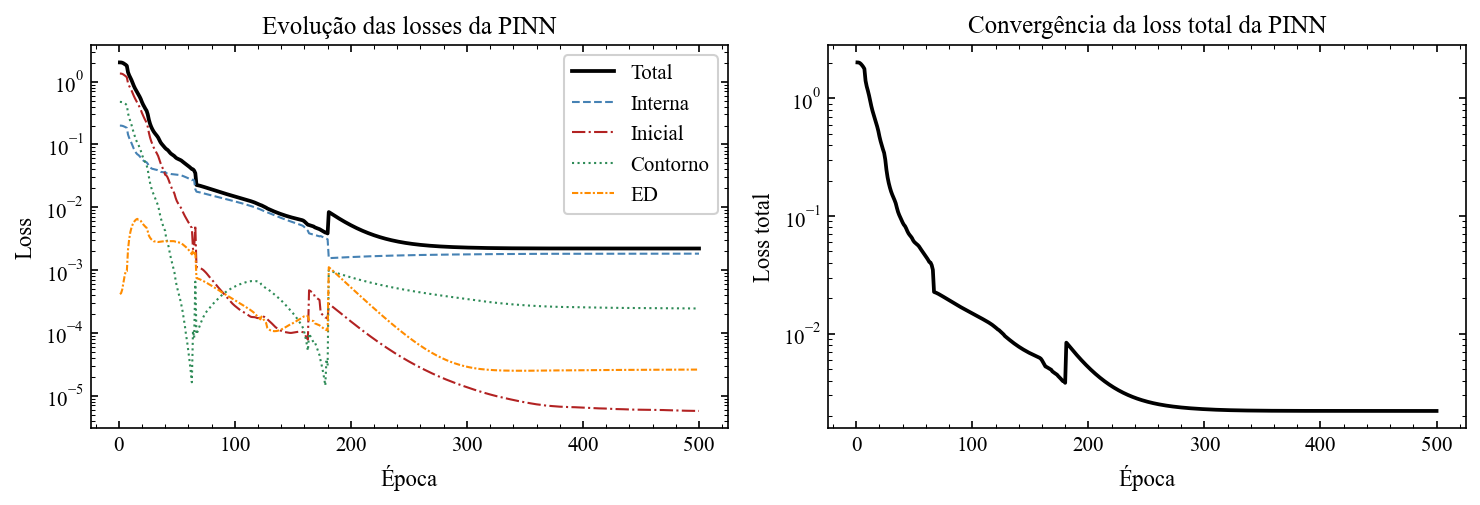

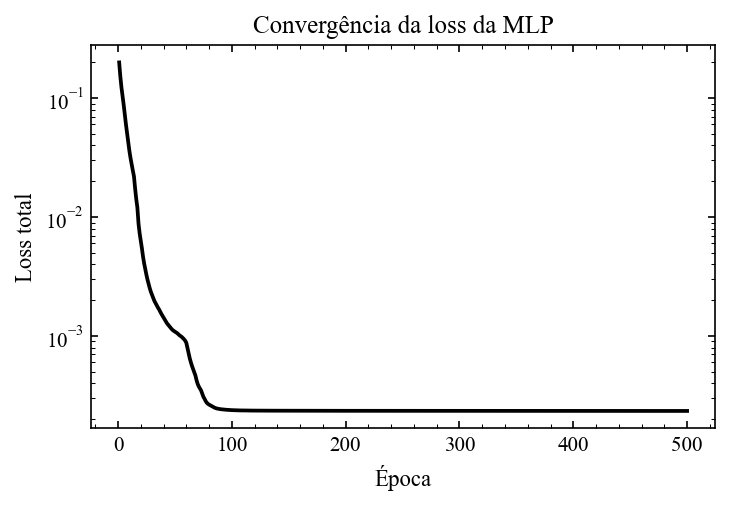

In [18]:
plot_losses(historico_pinn, nome_modelo='PINN', salvar=True, nome_arquivo='../Imagens/Resultados/Inverso/losses_pinn_inversa')
plot_losses(historico_mlp,  nome_modelo='MLP',  salvar=True, nome_arquivo='../Imagens/Resultados/Inverso/losses_mlp_inversa')

Abaixo estão os gráficos das perdas para os **modelos treinados com pontos equidistantes**.

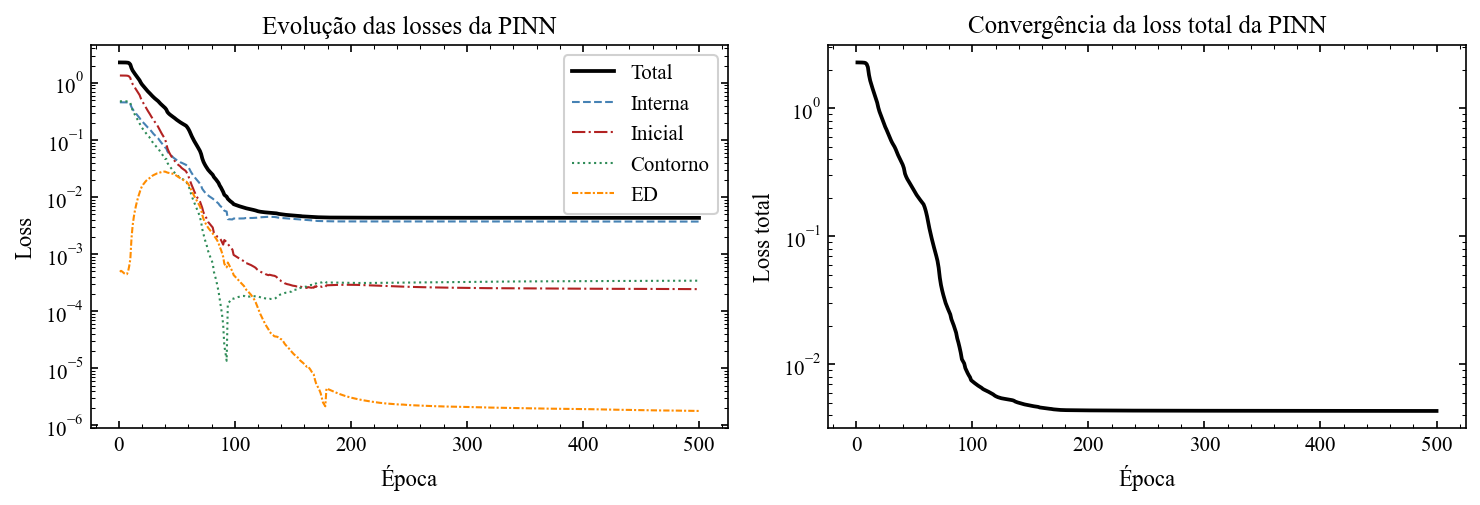

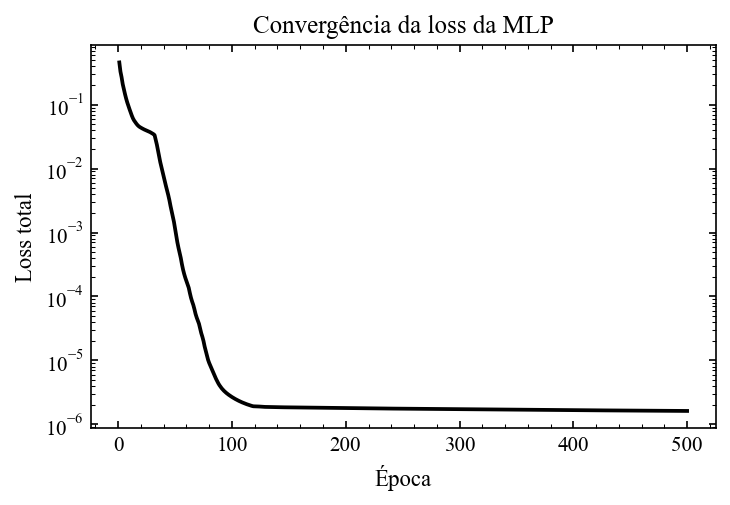

In [19]:
plot_losses(historico_pinn_eq, nome_modelo='PINN', salvar=True, nome_arquivo='../Imagens/Resultados/Inverso/losses_pinn_eq_inversa')
plot_losses(historico_mlp_eq,  nome_modelo='MLP',  salvar=True, nome_arquivo='../Imagens/Resultados/Inverso/losses_mlp_eq_inversa')

Note que é comum a função de perda da MLP ter valor menor que o da PINN, mas não se preocupe. Aqui a função perda é calculada no treino com os dados de treino, então é bem possível que isso seja devido a um *overfit* da MLP, pois estamos trabalhando com poucos pontos de colocação com ruído no valor de alvo (e distribuídos aleatoriamente para o primeiro dos conjuntos de gráficos).

### 5.9.2 Gráficos de solução: modelo X solução analítica

Abaixo são plotados gráficos de comparação com a solução analítica do problema. Para cada tipo de malha (pontos aleatórios ou equidistantes) são plotados os gráficos para dois intervalos de tempo diferentes: um deles vai até $t_{\mathrm{max}}$ e o outro até $2t_{\mathrm{max}}$ a fim de averiguar (visualmente) as capacidades de **interpolação** e **extrapolação** dos modelos, respectivamente.

# ############################################################### #
     Plots para malha de pontos aleatórios
# ############################################################### #
# --------------------------------------------- #
     Plots para limite máximo de t = 500.0
# --------------------------------------------- #


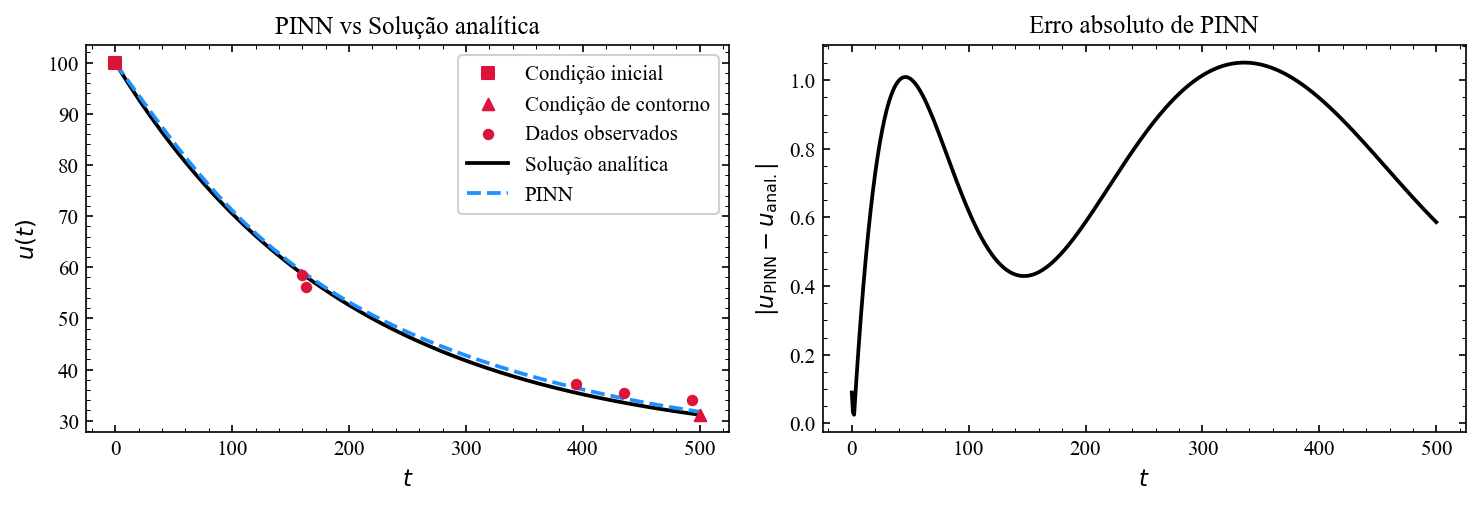

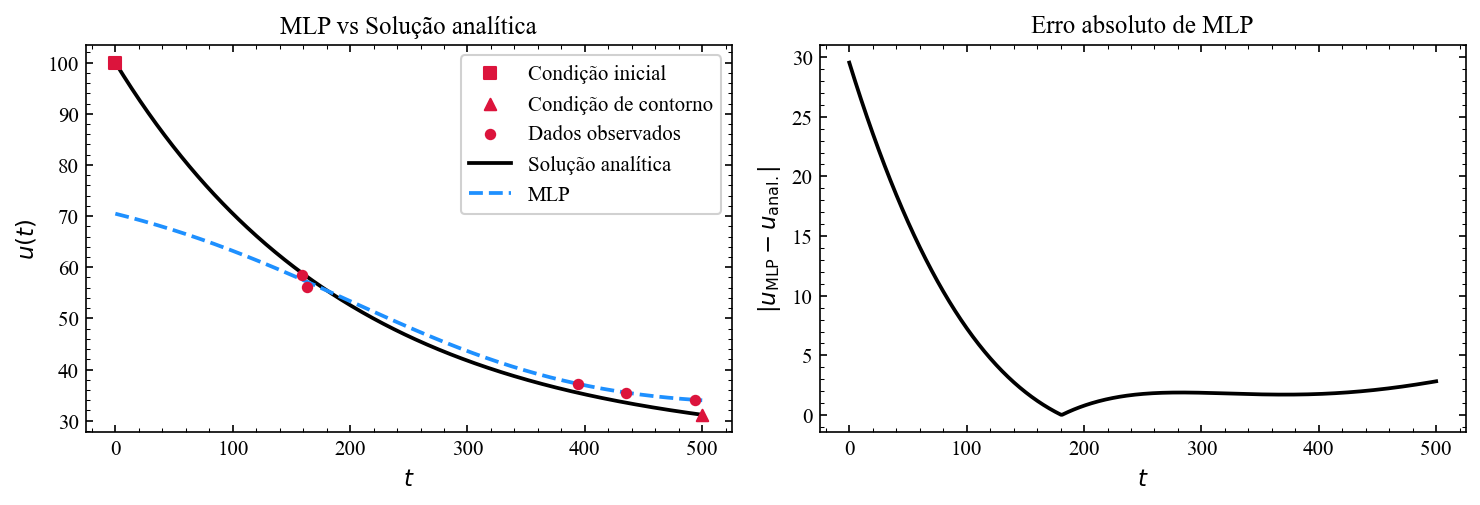

# --------------------------------------------- #
     Plots para limite máximo de t = 1000.0
# --------------------------------------------- #


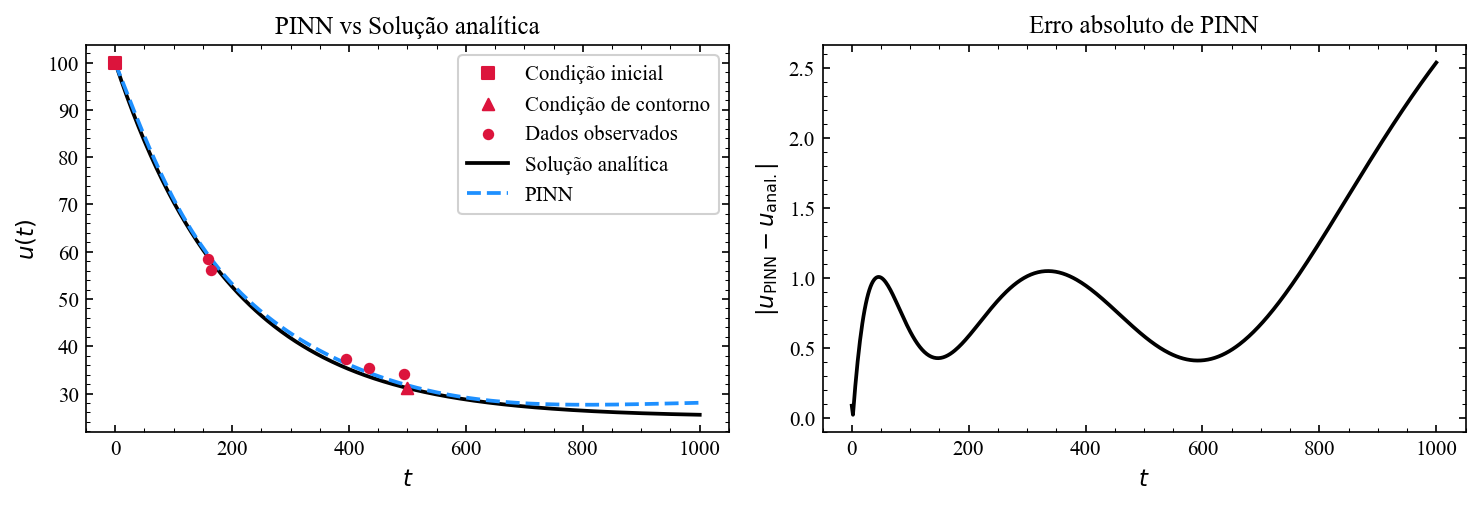

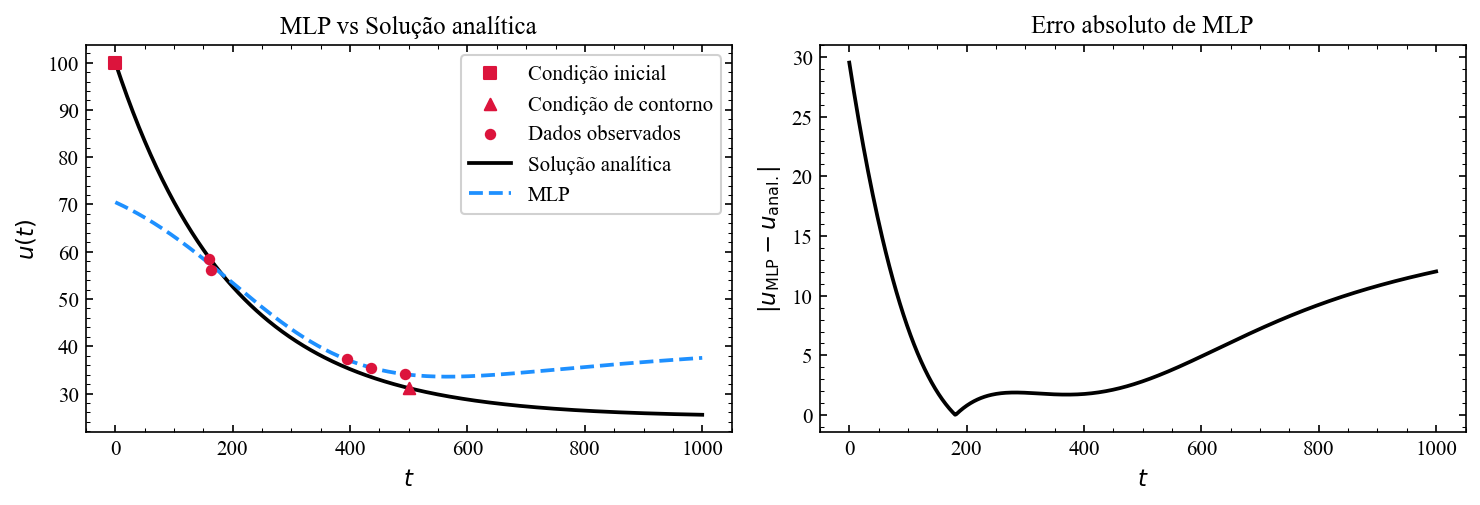

# ############################################################### #
     Plots para malha de pontos equidistantes
# ############################################################### #
# --------------------------------------------- #
     Plots para limite máximo de t = 500.0
# --------------------------------------------- #


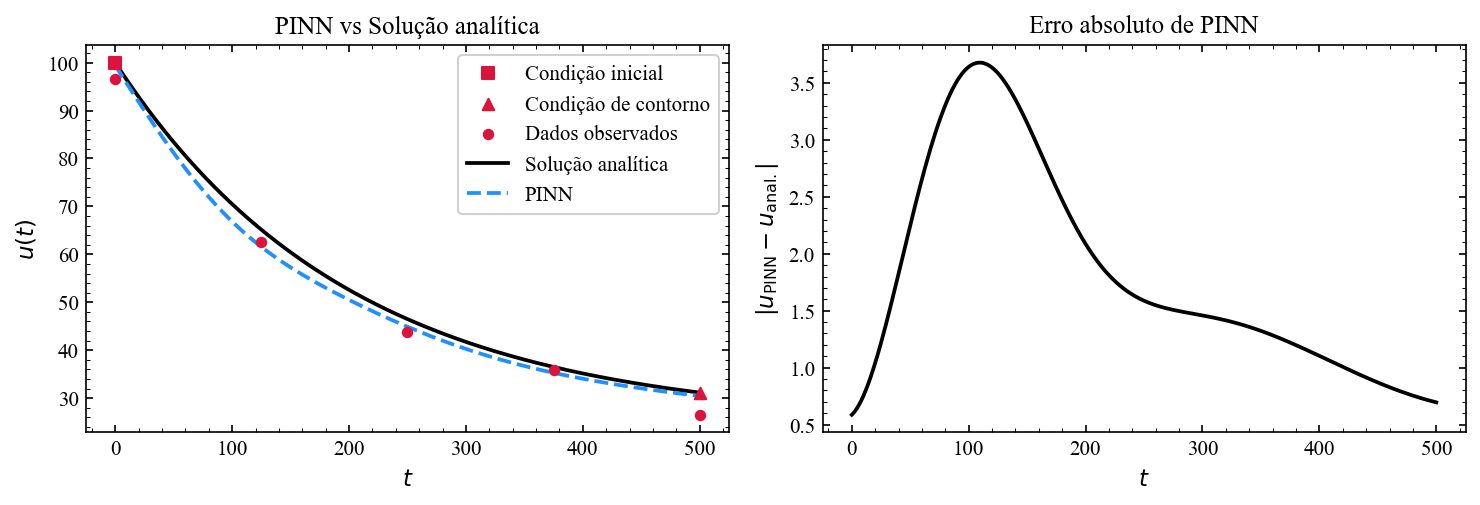

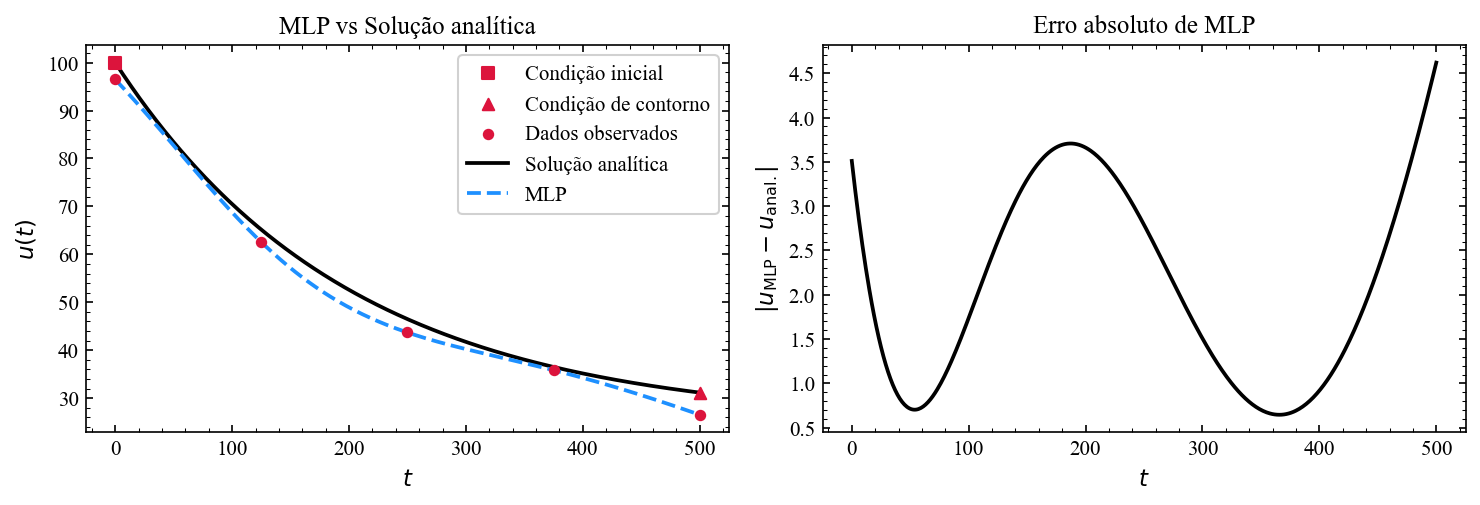

# --------------------------------------------- #
     Plots para limite máximo de t = 1000.0
# --------------------------------------------- #


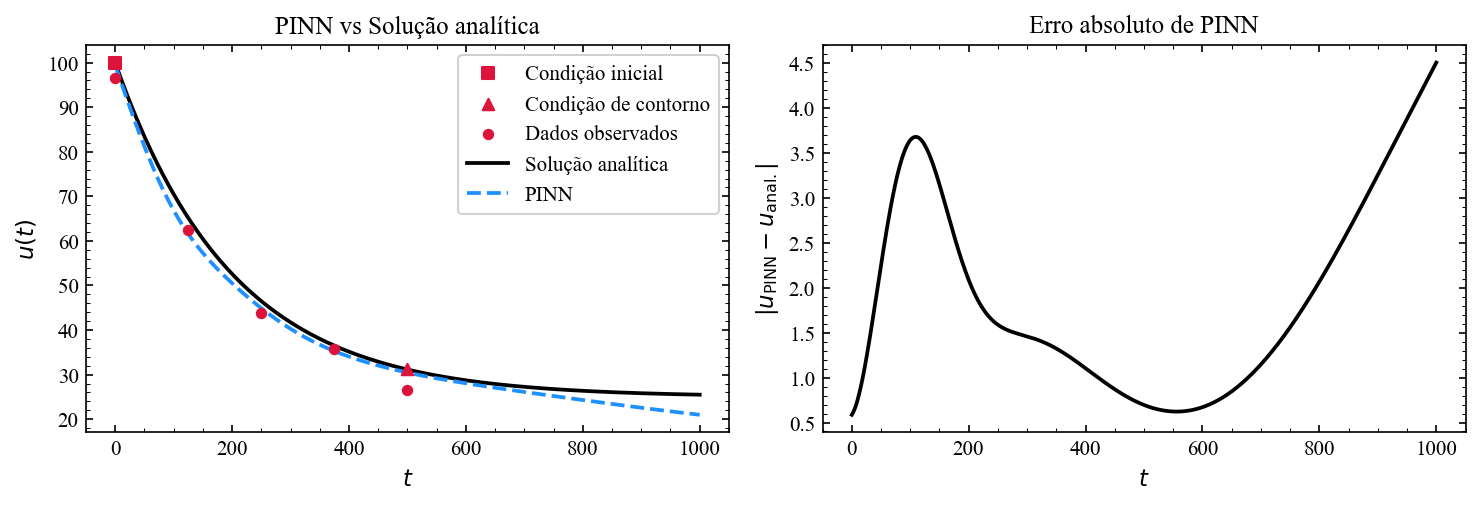

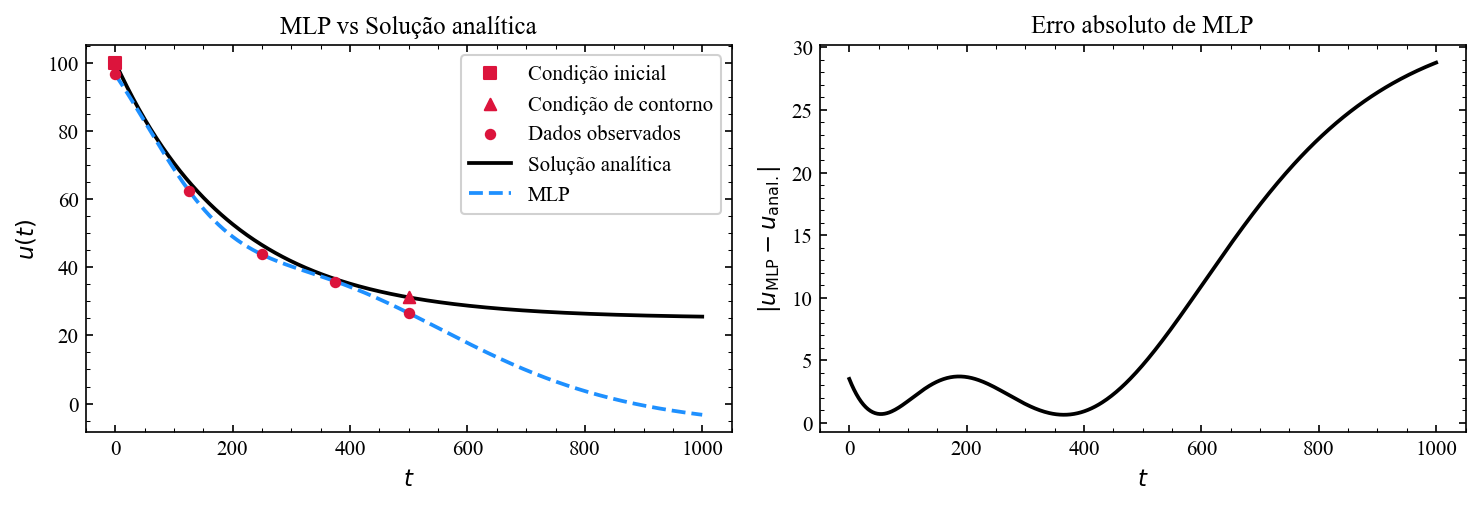

In [20]:
limite_t = [t_max, 2*t_max]
malhas = {"pontos aleatórios": (pinn, mlp, malha_interna, u_interno), 
          "pontos equidistantes": (pinn_eq, mlp_eq, malha_interna_eq, u_interno_eq)}

for malha in malhas:

    print('# ############################################################### #')
    print(f'     Plots para malha de {malha}')
    print('# ############################################################### #')
    
    for lim_t in limite_t:
    
        # Previsão PINN
        t_plot, u_pinn = prever(
            modelo=malhas[malha][0],
            t_min=t_min, 
            t_max=t_max, 
            t_min_prev=t_min, 
            t_max_prev=lim_t,   # limte máximo de t
            norm=True, 
            u_min=u_min, 
            u_max=u_max
        )

        # Previsão MLP
        _, u_mlp = prever(
            modelo=malhas[malha][1],
            t_min=t_min, 
            t_max=t_max, 
            t_min_prev=t_min, 
            t_max_prev=lim_t,   # limite máximo de t 
            norm=True, 
            u_min=u_min, 
            u_max=u_max
        )

        print('# --------------------------------------------- #')
        print(f'     Plots para limite máximo de t = {lim_t}')
        print('# --------------------------------------------- #')
    
        # Plot PINN
        plot_solucao(
            solucao_analitica=solucao_analitica_parcial,
            t_plot=t_plot,
            u_prev=u_pinn,
            malha_interna=malhas[malha][2],
            u_interno=malhas[malha][3],
            u_inicial=u_inicial,
            u_contorno=u_contorno,
            t_min=t_min,
            t_max=t_max,
            nome_modelo='PINN',
            norm=True,
            u_min=u_min,
            u_max=u_max,
            salvar=True,
            nome_arquivo=f'../Imagens/Resultados/Inverso/solucao_pinn{"_eq" if malha == "pontos equidistantes" else ""}{"_1" if lim_t == t_max else "_2"}_inversa'
        )

        # Plot MLP
        plot_solucao(
            solucao_analitica=solucao_analitica_parcial,
            t_plot=t_plot,
            u_prev=u_mlp,
            malha_interna=malhas[malha][2],
            u_interno=malhas[malha][3],
            u_inicial=u_inicial,
            u_contorno=u_contorno,
            t_min=t_min,
            t_max=t_max,
            nome_modelo='MLP',
            norm=True,
            u_min=u_min,
            u_max=u_max,
            salvar=True,
            nome_arquivo=f'../Imagens/Resultados/Inverso/solucao_mlp{"_eq" if malha == "pontos equidistantes" else ""}{"_1" if lim_t == t_max else "_2"}_inversa'
        )

## 5.10 Discussão de resultados

Observe que, apesar da MLP possuir uma loss menor que a PINN, os gráficos reforçam a idea de que a <b>MLP sofreu *overfit*</b> e apontam para que a PINN não, evidenciando a diferença crucial que considerar a Equação Diferencial como parte da função de perda faz para treino com poucos dados ruidosos. Observe também **a diferença que os pontos equidistantes fazem para a MLP** conseguir acompanhar o formato da solução analítica, enquanto a **PINN consegue acompanhá-la bem independentemente**.

A regularização da PINN via MSE do **resíduo da equação diferencial a força a seguir o comportamento esperado** na solução de decaimento exponencial, enquanto os **valores inicial** e de **contorno** ajudam a **"fixar" a solução particular** correta. A MLP, por não possuir nenhum desses termos extras na função de perda, sofre sobreajuste e foge completamente da solução esperada.

A PINN, mesmo sem saber um dos parâmetros da ED, conseguiu compreender e generalizar os dados muito bem, diferente da MLP.

-------------------------

# 6. Conclusões

Vimos que as Redes Neurais Informadas por Física (do inglês *Physics Informed Neural Network*, PINN) são um tipo de rede neural voltado para a generalização do comportamento de dados regidos por equações diferenciais. **A principal diferença das PINNs para uma MLP está no uso do resíduo da equação diferencial** para adicionar um termo no cálculo da função de perda para regularização dela, limitando-a a seguir a dinâmica já conhecida do sistema. Mas não é a única diferença: considerar condição inicial e de contorno também faz uma grande diferença.

Montamos uma PINN passo a passo a partir de uma MLP e treinamos ambas redes num problema regido pela Lei de Resfriamento de Newton. Ao realizar o teste dos modelos, observamos que a PINN performou melhor que a MLP, que sofreu *overfit*, demonstrando **capacidade de generalização com poucos dados experimentais dispersos e ruidosos mesmo sem saber um dos parâmetros da equação diferencial**.

-------------------------

# 7. Referências

[1] REN, Zhiyuan; ZHOU, Shijie; LIU, Dong; LIU, Qihe. Physics-Informed Neural Networks: a review of methodological evolution, theoretical foundations, and interdisciplinary frontiers toward next-generation scientific computing. Applied Sciences, Basel, MDPI, 2025. DOI: https://doi.org/10.3390/app15148092. Disponível em: https://www.mdpi.com/2076-3417/15/14/8092. Acesso em: 10 maio 2026.

[2] RAISSI, Maziar; PERDIKARIS, Paris; KARNIADAKIS, George Em. Physics-informed neural networks: a deep learning framework for solving forward and inverse problems involving nonlinear partial differential equations. Journal of Computational Physics, v. 378, p. 686–707, fev. 2019. DOI: https://doi.org/10.1016/j.jcp.2018.10.045. Disponível em: https://www.sciencedirect.com/science/article/abs/pii/S0021999118307125. Acesso em: 10 maio 2026.

[3] WIKIPEDIA. Limited-memory BFGS. Wikimedia Foundation, 2024. Disponível em: https://en.wikipedia.org/wiki/Limited-memory_BFGS. Acesso em: 10 maio 2026.

[4] PYTORCH. torch.optim.LBFGS. In: PyTorch Documentation, versão 2.11. Disponível em: https://docs.pytorch.org/docs/2.11/generated/torch.optim.LBFGS.html. Acesso em: 10 maio 2026.

[5] WOLF, Theo. Physics-Informed Neural Networks: a simple tutorial with PyTorch. Medium, 2023. Disponível em: https://medium.com/@theo.wolf/physics-informed-neural-networks-a-simple-tutorial-with-pytorch-f28a890b874a. Acesso em: 10 maio 2026.

[6] NGUYEN, Khoa. pinns.py. GitHub, 2023. Disponível em: https://github.com/nguyenkhoa0209/pinns_tutorial/blob/main/pinns.py. Acesso em: 10 maio 2026.

------------------------

# 8. XKCD irrelevante

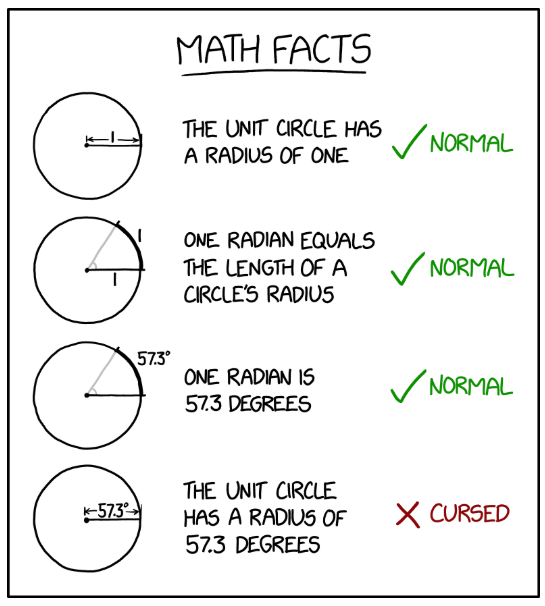

`Imagem: Randians are Cursed (XKCD). Disponível em: https://xkcd.com/2748/`